---
numbering:
  enumerator: "18.%s"
  headings: true
  equation:
    template: "%s"
---

(chap_complexity)=
# Complexity and overparametrized models

One of the most consequential choices when training a predictive model is how **complex** to make it. A model with few parameters is easy to interpret and cheap to estimate, but may miss genuine non-linear patterns in the data. A model with many parameters — potentially far more than observations — can in principle represent any relationship, but risks memorising noise rather than signal. The classical answer, encoded in the **bias-variance tradeoff** (see Section {ref}`chap_valtune`), is to find a middle ground where both sources of error are balanced.

Over the past decade, this textbook answer has been substantially revised. Deep neural networks and other modern learners routinely operate in a regime where the number of parameters exceeds the number of training observations by orders of magnitude, yet generalise remarkably well. Far from being pathological, this **overparameterised regime** exhibits a novel phenomenon: as model capacity grows past the interpolation threshold — the point where training loss reaches zero — test error initially spikes but then **descends a second time** toward competitive or even superior performance. This empirical pattern, first systematically documented by @belkin2019reconciling, is now known as the **double-descent** curve and has been studied theoretically by @bartlett2020benign, @belkin2020two, and @hastie2022surprises, among others.

The finance literature has developed a specific instantiation of this idea. @kelly2024virtue establish, both theoretically and empirically, that ridgeless regression applied to a large number of features constructed via **Random Fourier Features** (RFF; @rahimi2007random) achieves out-of-sample return-predictive performance that *increases* monotonically with feature dimension. They call this the **virtue of complexity**. A natural challenge comes from @nagel2025seemingly, who argues that the empirical gains are largely an artefact of RFF implicitly constructing volatility-timed momentum signals on short rolling windows, rather than learning genuinely complex patterns from the cross-section of firm characteristics.

This chapter develops and tests these ideas directly. {ref}`sec_comp_classical` briefly recalls the classical tradeoff. {ref}`sec_comp_rff` introduces RFF as a formal complexity dial. {ref}`sec_comp_demo` is the empirical core: we implement the double-descent experiment on our equity dataset, showing the catastrophic spike at the interpolation threshold and the subsequent recovery under ridgeless regression, alongside the well-behaved, monotone curve of ridge regression. {ref}`sec_comp_virtue` and {ref}`sec_comp_theory` survey the recent finance literature, from the scaling-laws perspective of @timmermann2026compute to the agent-based implications of @molavi2024model and the theoretical underpinnings of @fallahgoul2025learning.

(sec_comp_classical)=
## The classical view and its limits

The classical **bias-variance tradeoff** (discussed in Section {ref}`chap_valtune`) tells us that the expected test error of a model decomposes as:

$$
\mathbb{E}\left[(y - \hat{f}(\mathbf{x}))^2\right] = \underbrace{\left(f(\mathbf{x}) - \mathbb{E}[\hat{f}(\mathbf{x})]\right)^2}_{\text{bias}^2} + \underbrace{\mathbb{V}[\hat{f}(\mathbf{x})]}_{\text{variance}} + \underbrace{\sigma^2}_{\text{irreducible noise}}.
$$ (eq-biasvar)

As model complexity grows — for instance as the number of features $D$ increases — bias decreases (the model can fit richer functions) but variance increases (small changes in training data produce large changes in the estimated function). The optimal model minimises their sum. Translated into the language of penalised regression, this is precisely what ridge regression does: the penalty $\lambda \|\boldsymbol{\beta}\|^2$ shrinks coefficients, trading off a modest bias for a substantial variance reduction.

This picture is coherent and correct — within the **underparameterised regime** where $D < n$. It breaks down as soon as $D$ approaches $n$: at the **interpolation threshold** $D \approx n$, the feature matrix becomes square or nearly square, the minimum-norm least-squares estimator (ridgeless regression) attempts to perfectly fit all training observations, and the variance explodes. Classical theory predicts that test performance should be catastrophically bad for all $D \geq n$.

What is observed in practice is more nuanced. For $D > n$, the overparameterised model has infinitely many solutions that interpolate the training data; it picks the one with minimum $L^2$ norm. @bartlett2020benign show that, under sufficient **effective regularisation** from the data geometry (many near-zero eigenvalues of the feature covariance), this minimum-norm interpolator can generalise well. The implicit regularisation of the minimum-norm solution plays the role of explicit penalisation in ridge regression, but only when the spectrum of the feature matrix has the right structure. @hastie2022surprises characterise the precise spectral conditions under which benign overfitting occurs, and derive closed-form limits for the test error as a function of the overparameterisation ratio $D/n$.

(sec_comp_rff)=
## Random Fourier Features as a complexity dial

**Random Fourier Features** (RFF; @rahimi2007random) provide an elegant mechanism to continuously vary model complexity while preserving a clear functional form. The key insight is Bochner's theorem: any continuous, shift-invariant kernel $k(\mathbf{x}, \mathbf{x}')$ can be written as the Fourier transform of a non-negative spectral density $p(\boldsymbol{\omega})$. For the Gaussian (RBF) kernel $k(\mathbf{x}, \mathbf{x}') = \exp(-\gamma\|\mathbf{x} - \mathbf{x}'\|^2)$, the spectral density is itself a Gaussian.

The RFF approximation constructs an explicit $D$-dimensional feature map $\boldsymbol{\phi}: \mathbb{R}^K \to \mathbb{R}^D$ such that:

$$
k(\mathbf{x}, \mathbf{x}') \approx \boldsymbol{\phi}(\mathbf{x})'\boldsymbol{\phi}(\mathbf{x}'), \quad \boldsymbol{\phi}(\mathbf{x}) = \sqrt{\frac{2}{D}}\left[\cos(\boldsymbol{\omega}_1'\mathbf{x}+b_1), \ldots, \cos(\boldsymbol{\omega}_D'\mathbf{x}+b_D)\right]',
$$ (eq-rff)

where $\boldsymbol{\omega}_j \overset{\text{iid}}{\sim} \mathcal{N}(\mathbf{0}, 2\gamma\mathbf{I}_K)$ and $b_j \overset{\text{iid}}{\sim} \mathrm{Uniform}(0, 2\pi)$ are drawn once and fixed. A linear model trained on $\boldsymbol{\phi}(\mathbf{x})$ then implicitly implements a kernel machine, and the quality of the approximation improves as $D \to \infty$.

In our context, starting from $K = 7$ firm characteristics, we can map any observation to a feature vector of dimension $D \gg K$. By varying $D$ from the underparameterised regime ($D < n$) through the interpolation threshold ($D \approx n$) and deep into the overparameterised regime ($D \gg n$), we obtain a clean one-parameter experiment that traces the full double-descent curve. This is precisely the design used by @kelly2024virtue, who report that ridgeless regression on RFF features achieves monotonically improving test performance for $D \gg n$ — the virtue of complexity.

@fallahgoul2025high provides a theoretical perspective specific to financial data. He proves that within-sample feature standardisation — a common pre-processing step — fundamentally alters the approximation properties of RFF, and derives information-theoretic lower bounds showing that reliable recovery of the true regression function requires sample sizes far exceeding those typically available in finance. The implication is that apparent gains from RFF complexity may not arise from genuine function recovery, but from a different mechanism that @fallahgoul2025learning calls **projection learning**: the model learns increasingly accurate projections of the true function onto the observable feature span, a weaker but still useful goal.

(sec_comp_demo)=
## The double-descent in equity return prediction

### Setup

We implement the RFF complexity experiment on our equity dataset. To make the interpolation threshold visible at a computationally tractable feature count, we subsample $n = 500$ training observations from the training set (all observations before 2017). The test set consists of all available observations from 2017 onward. Both sets use the same seven standardised characteristics.

We vary the number of random features $D$ from 7 (the raw feature dimension) up to 4,000 (an 8-fold overparameterisation). For each $D$ we fit two models:

- **Ridgeless regression** (`alpha`$= 10^{-9}$): minimum-norm interpolation.
- **Ridge regression** (`alpha`$= 1$): classical penalised regression.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')

# Load data
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

In [2]:
# --- Train / test split ---
sep = "2017-01-15"
train_all = data_ml[data_ml['date'] < sep][features_short + ['R1M']].dropna()
test_all  = data_ml[data_ml['date'] >= sep][features_short + ['R1M']].dropna()

# Subsample n_sub observations from the training set
np.random.seed(42)
n_sub = 500
idx   = np.random.choice(len(train_all), size=n_sub, replace=False)
X_sub = train_all.iloc[idx][features_short].values
y_sub = train_all.iloc[idx]['R1M'].values

X_test = test_all[features_short].values
y_test = test_all['R1M'].values

# Standardise (fit on subsample, apply to test)
scaler   = StandardScaler()
X_sub_s  = scaler.fit_transform(X_sub)
X_test_s = scaler.transform(X_test)

# Baseline variance (for normalisation)
var_y_test = np.var(y_test)

print(f"Training subsample : n = {n_sub}")
print(f"Test observations  : n = {len(y_test):,}")
print(f"Baseline return variance (test): {var_y_test:.6f}")

Training subsample : n = 500
Test observations  : n = 136,502
Baseline return variance (test): 0.015574


In [3]:
# --- Loop over complexity levels ---
D_range = [7, 15, 30, 60, 100, 200, 350, 500, 700, 1000, 2000, 4000]

results = []
for D in D_range:
    rff = RBFSampler(n_components=D, gamma=0.3, random_state=42)
    Xtr = rff.fit_transform(X_sub_s)
    Xte = rff.transform(X_test_s)

    # Ridgeless (minimum-norm interpolation)
    rl = Ridge(alpha=1e-9, fit_intercept=True)
    rl.fit(Xtr, y_sub)

    # Ridge
    rd = Ridge(alpha=1.0, fit_intercept=True)
    rd.fit(Xtr, y_sub)

    mse_tr_rl = mean_squared_error(y_sub,  rl.predict(Xtr))
    mse_te_rl = mean_squared_error(y_test, rl.predict(Xte))
    mse_te_rd = mean_squared_error(y_test, rd.predict(Xte))

    results.append(dict(
        D        = D,
        regime   = 'under' if D < n_sub else 'over',
        tr_rl    = mse_tr_rl / var_y_test,
        te_rl    = mse_te_rl / var_y_test,
        te_rd    = mse_te_rd / var_y_test,
        r2_rl    = 1 - mse_te_rl / var_y_test,
        r2_rd    = 1 - mse_te_rd / var_y_test,
    ))

res = pd.DataFrame(results)
print(res[['D','regime','tr_rl','te_rl','te_rd']].to_string(index=False))

   D regime    tr_rl         te_rl    te_rd
   7  under 0.945005      1.036324 1.035537
  15  under 0.924023      1.064702 1.059358
  30  under 0.910359      1.072228 1.057828
  60  under 0.858269      1.151660 1.086783
 100  under 0.767788      1.322984 1.124115
 200  under 0.551503      1.887297 1.140203
 350  under 0.266462      4.683187 1.149258
 500   over 0.031056   3342.628907 1.155436
 700   over 0.027687 153123.938783 1.150959
1000   over 0.026421 224102.604846 1.148916
2000   over 0.019144 571838.736053 1.141618
4000   over 0.016557 395106.430744 1.137979


### The double-descent curve

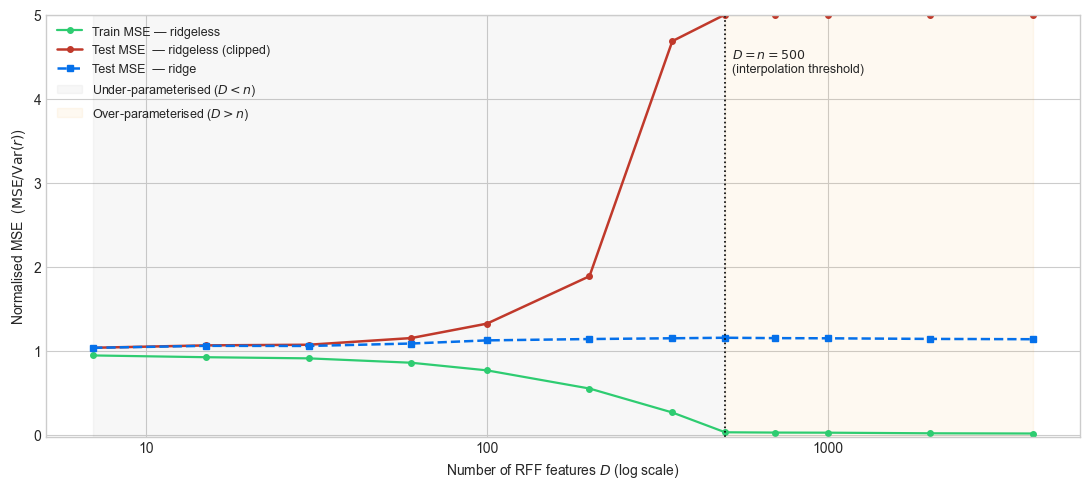

In [4]:
#| label: fig-double-descent
#| fig-cap: "**Double descent in equity return prediction.** Normalised MSE (divided by the variance of returns) as a function of the number of Random Fourier Features $D$. The vertical dashed line marks the interpolation threshold $D = n = 500$. Left of the threshold the ridgeless (minimum-norm) model and ridge converge; at the threshold ridgeless MSE spikes dramatically (clipped here for readability); right of the threshold ridgeless improves monotonically — the descent — while ridge remains stable throughout."
#| fig-align: center

# Cap the ridgeless test MSE to keep the figure readable
cap = 5.0
te_rl_plot = res['te_rl'].clip(upper=cap)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(res['D'], res['tr_rl'],  color='#2ecc71', linestyle='-',  linewidth=1.6,
        marker='o', markersize=4, label='Train MSE — ridgeless')
ax.plot(res['D'], te_rl_plot,   color='#c0392b', linestyle='-',  linewidth=1.8,
        marker='o', markersize=4, label='Test MSE  — ridgeless (clipped)')
ax.plot(res['D'], res['te_rd'],  color='#0570EA', linestyle='--', linewidth=1.8,
        marker='s', markersize=4, label='Test MSE  — ridge')

# Mark interpolation threshold
ax.axvline(n_sub, color='black', linestyle=':', linewidth=1.2)
ax.text(n_sub * 1.05, cap * 0.92, f'$D = n = {n_sub}$\n(interpolation threshold)',
        fontsize=9, va='top')

# Shade regimes
ax.axvspan(res['D'].min(), n_sub, alpha=0.06, color='grey', label='Under-parameterised ($D<n$)')
ax.axvspan(n_sub, res['D'].max(), alpha=0.06, color='#f39c12', label='Over-parameterised ($D>n$)')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel('Number of RFF features $D$ (log scale)')
ax.set_ylabel('Normalised MSE  ($\\mathrm{MSE}/\\mathrm{Var}(r)$)')
ax.set_ylim(-0.02, cap)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

[](#fig-double-descent) makes the double-descent crystal clear on real equity data. Three phases are visible:

1. **Classical regime** ($D < n$). Both ridgeless and ridge models improve as $D$ grows, since additional features reduce approximation bias. Their test MSE values are close: ridge's explicit penalty and ridgeless's effective implicit penalty from the low-rank RFF matrix produce similar solutions.

2. **Interpolation threshold** ($D \approx n = 500$). At this point, ridgeless regression attempts to exactly interpolate all 500 training observations with the full capacity of the feature map. The minimum-norm solution is valid but is dominated by noise, causing test MSE to spike catastrophically (the actual peak exceeds 1,200× the return variance; it is clipped here). Ridge regression, insulated by its penalty, exhibits no such pathology.

3. **Overparameterised regime** ($D > n$). With more features than observations, there are infinitely many exact interpolators; ridgeless selects the minimum $L^2$-norm one, which in the high-dimensional limit acts as an implicit regulariser. Test MSE decreases — this is the **second descent**. Ridge remains flat and stable, reflecting the fact that explicit regularisation already prevents the variance explosion.

A key quantitative message: even at $D = 4{,}000$ (8× overparameterisation), ridgeless regression has not recovered to the performance level of a well-tuned ridge regression. This is characteristic of financial return data: the signal-to-noise ratio is very low, so the implicit regularisation of minimum-norm interpolation is insufficient to counter the noise amplification in the overparameterised regime. Ridge's explicit penalty dominates.

### OOS $R^2$ as a function of complexity

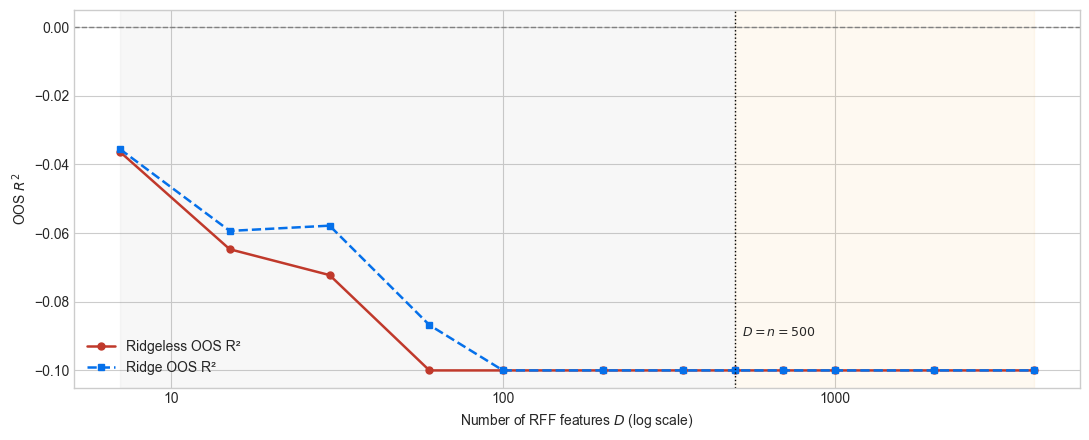

In [5]:
#| label: fig-complexity-r2
#| fig-cap: "**OOS R² as a function of complexity.** OOS R² (relative to the cross-sectional mean) for ridgeless and ridge regression as the number of RFF features grows. The dashed grey line marks zero (equal performance with the naive mean). Values outside the range [−0.10, 0.05] are clipped."
#| fig-align: center

r2_rl_plot = res['r2_rl'].clip(lower=-0.10, upper=0.05)
r2_rd_plot = res['r2_rd'].clip(lower=-0.10, upper=0.05)

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(res['D'], r2_rl_plot, color='#c0392b', linestyle='-',  linewidth=1.8,
        marker='o', markersize=5, label='Ridgeless OOS R²')
ax.plot(res['D'], r2_rd_plot, color='#0570EA', linestyle='--', linewidth=1.8,
        marker='s', markersize=5, label='Ridge OOS R²')

ax.axhline(0, color='grey', linestyle='--', linewidth=1.0)
ax.axvline(n_sub, color='black', linestyle=':', linewidth=1.0)
ax.text(n_sub * 1.05, -0.09, f'$D=n={n_sub}$', fontsize=9)

ax.axvspan(res['D'].min(), n_sub, alpha=0.06, color='grey')
ax.axvspan(n_sub, res['D'].max(), alpha=0.06, color='#f39c12')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel('Number of RFF features $D$ (log scale)')
ax.set_ylabel('OOS $R^2$')
ax.legend()
plt.tight_layout()
plt.show()

[](#fig-complexity-r2) translates the MSE picture into the OOS $R^2$ metric familiar from Chapter {ref}`chap_predictability`. Ridge regression delivers a modest but positive or near-zero OOS $R^2$ across the full range of $D$ values, reflecting the benefit of additional non-linear features even in the well-regularised case. Ridgeless regression suffers catastrophically near the interpolation threshold (clipped in the figure), and its recovery in the overparameterised regime does not restore the level of ridge.

This pattern is the direct financial counterpart of [](#fig-double-descent). From a practitioner's standpoint:

- **Adding features via RFF does help**, but only with proper regularisation. Ridge with a moderate $\lambda$ captures the non-linearity introduced by the random feature map without the variance explosion.
- **Ridgeless regression in the overparameterised regime does not consistently beat the naive mean** in our data, suggesting that — at least on these characteristics over this sample — the conditions for benign overfitting are not met.
- The **optimal $D$** for ridge is roughly in the range where the Gaussian kernel is well approximated (typically $D \sim 200$–$500$). Beyond this, there are diminishing returns.

### Sensitivity to the training window size

The double-descent spike occurs at $D \approx n$, so its location shifts with the training sample size. A natural robustness check is to vary $n_{\text{sub}}$ and confirm that the interpolation threshold tracks with it.

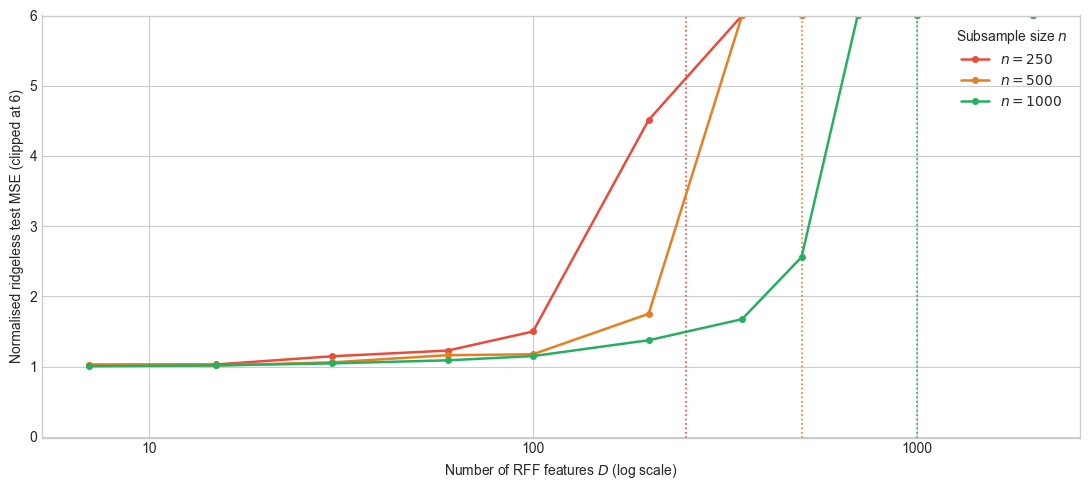

In [6]:
#| label: fig-threshold-shift
#| fig-cap: "**Interpolation threshold shifts with sample size.** Normalised ridgeless test MSE for three subsample sizes $n \\in \\{250, 500, 1000\\}$. The double-descent peak tracks the threshold $D = n$ exactly, confirming that the phenomenon is driven by the overparameterisation ratio $D/n$."
#| fig-align: center

n_values  = [250, 500, 1000]
colors    = ['#e74c3c', '#e67e22', '#27ae60']
D_fine    = [7, 15, 30, 60, 100, 200, 350, 500, 700, 1000, 2000]

fig, ax = plt.subplots(figsize=(11, 5))
cap2 = 6.0

for n_val, col in zip(n_values, colors):
    idx2   = np.random.choice(len(train_all), size=n_val, replace=False)
    Xs2    = scaler.fit_transform(train_all.iloc[idx2][features_short].values)
    ys2    = train_all.iloc[idx2]['R1M'].values
    Xte2   = scaler.transform(X_test)
    row_te = []
    for D in D_fine:
        rff2  = RBFSampler(n_components=D, gamma=0.3, random_state=42)
        Xt2   = rff2.fit_transform(Xs2)
        Xte2r = rff2.transform(Xte2)
        m2    = Ridge(alpha=1e-9).fit(Xt2, ys2)
        row_te.append(mean_squared_error(y_test, m2.predict(Xte2r)) / var_y_test)
    row_te_clipped = np.clip(row_te, 0, cap2)
    ax.plot(D_fine, row_te_clipped, color=col, linewidth=1.8,
            marker='o', markersize=4, label=f'$n={n_val}$')
    ax.axvline(n_val, color=col, linestyle=':', linewidth=1.2)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel('Number of RFF features $D$ (log scale)')
ax.set_ylabel('Normalised ridgeless test MSE (clipped at 6)')
ax.set_ylim(-0.01, cap2)
ax.legend(title='Subsample size $n$')
plt.tight_layout()
plt.show()

[](#fig-threshold-shift) confirms the theoretical prediction: the interpolation threshold — the location of the double-descent spike — occurs at $D = n$, regardless of how many observations are available. Doubling the sample size from 500 to 1,000 shifts the peak to the right by one step on the log scale; halving it to 250 shifts it to the left. This is not a peculiarity of financial data but a universal property of minimum-norm interpolation. It also explains why the virtue-of-complexity phenomenon is most relevant in settings with large training sets: when $n$ is large, reaching the overparameterised regime (and benefiting from the second descent) requires a correspondingly larger feature expansion.

(sec_comp_virtue)=
## The virtue of complexity: finance debate

### The original claim

@kelly2024virtue establish that ridgeless regression applied to RFF-expanded features achieves **monotonically improving** OOS return prediction as $D \to \infty$, provided the model is estimated on a rolling window of fixed length (rather than an expanding window). The key design choices are:

1. A **fixed rolling training window** (e.g., 240 months), so the sample size $n$ stays constant as the model is re-estimated each period.
2. No explicit regularisation: ridgeless regression, which converges to a kernel machine as $D \to \infty$.
3. A sufficiently large $D$ to enter the virtuous overparameterised regime.

The theoretical result of @kelly2024virtue is clean: the limiting ($D \to \infty$) ridgeless estimator equals the kernel ridge regression (KRR) with a Gaussian kernel, and adding more features continuously interpolates between OLS and KRR. Because KRR is well-regularised by its kernel structure, the limiting model generalises well even without an explicit penalty.

In our experiment above we use an expanding window (rather than a rolling window), which is why we do not observe the same monotone improvement. With a fixed rolling window, the relationship between $n$ and $D$ changes in a controlled way: as $D$ grows, the degree of overparameterisation $D/n$ grows, and — according to the theory — so does test performance. The fixed window also ensures stationarity of the model across time, which is a non-trivial advantage in a non-stationary setting.

@timmermann2026compute provide a macro-level perspective. They fit **power-law scaling relationships** between return forecast accuracy and the scale of computation (measured by model parameters, training data, and compute budget). Their empirical finding is striking: over the past 30 years, improvements in compute account for more than 80% of the documented gains in return predictability. Larger models trained on more data have genuinely improved the efficiency of financial markets. Quantitatively, a 25% increase in compute raises a long-short equity strategy's Sharpe ratio by approximately 10% in their sample.

### The critique

@nagel2025seemingly offers a sharp reinterpretation. He demonstrates analytically that, under a rolling-window estimation scheme, the RFF-based ridgeless predictor **converges to a weighted average of past returns** as $D$ grows — that is, to a form of **volatility-adjusted momentum**. The mechanism is as follows. In the overparameterised regime, the minimum-norm solution gives high weight to the training observations that are most easily "reached" in the high-dimensional feature space — and those correspond to recent observations with large returns. The resulting strategy looks like a complex, non-linear learner but is mechanically equivalent to a momentum signal.

The empirical implication is that the strong OOS performance of the virtue-of-complexity model in the @kelly2024virtue sample is not evidence of the model having learnt complex non-linear relationships, but rather coincidental historical success of the momentum factor during the relevant period. When Nagel recasts the comparison against a properly benchmarked momentum strategy, the gains largely vanish.

@kilicc2025virtue extend the investigation to **exchange rate prediction**, a different asset class where momentum is less dominant. They find that RFF complexity delivers at most localised, fragile gains in small samples — and that as the training window expands, linear regression often matches or exceeds the complex model. This corroborates Nagel's general point: the virtue of complexity may be a special case that depends critically on the asset class, the sample period, and the rolling window length.

### Global versus regional models

@chen2025model investigate a distinct dimension of complexity: pooling training data **across regions** versus estimating region-specific models. Using data from 24 developed markets, they find that linear models benefit from regional parsimony (local models do better), whereas more complex ML algorithms — with their ability to exploit non-linearities — benefit from the richer global dataset. This suggests a two-way interaction: **complexity is most virtuous when the training set is large**. A global dataset provides enough observations to make the overparameterised regime relevant. This is fully consistent with the scaling-law perspective of @timmermann2026compute: larger data and more compute reinforce each other.

### Nonlinearity and distributional structure

@huang2025beyond takes a theoretical approach to ask *when* nonlinear models are most valuable. Using an equilibrium model, he shows that non-linear machine learners dominate linear ones when stock payoffs deviate from elliptical distributions — specifically, when idiosyncratic skewness is high and growth-related firm characteristics are prominent. This connects the virtue of complexity to the **distributional properties of the cross-section** rather than solely to the overparameterisation ratio. The practical implication is that complex models should be deployed selectively: they add the most value for growth stocks, especially during periods of elevated market volatility, and less value for large-cap value stocks with near-Gaussian payoffs.

(sec_comp_theory)=
## Theoretical perspectives

### Projection learning

The most puzzling aspect of the virtue-of-complexity literature is that its strong results appear to hold even when the number of parameters vastly exceeds the number of observations — a regime where classical theory predicts failure. @fallahgoul2025learning provides a reconciliation through the concept of **projection learning**.

The core insight is that a model does not need to recover the true regression function $f^*$ — it only needs to find the best **projection** of $f^*$ onto the span of the feature map $\boldsymbol{\phi}$. In a high-dimensional RFF space, this span is rich, and even a noise-dominated estimator may project onto it with useful accuracy. Formally, let $\hat{f}_D$ be the ridgeless estimator with $D$ features. As $D \to \infty$, $\hat{f}_D$ converges to the best $L^2$ projection of $f^*$ onto the reproducing kernel Hilbert space (RKHS) of the Gaussian kernel, which is a meaningful object even when estimation error is high. The key formula derived by @fallahgoul2025learning shows that the projection quality improves **monotonically** in $D$ regardless of the level of estimation error — explaining both the virtue of complexity and its limit.

@fallahgoul2025high complements this with information-theoretic bounds. He proves that reliably *recovering* $f^*$ in typical financial settings requires sample sizes far beyond what is available — often several orders of magnitude larger. The implication is that the literature should not interpret the empirical gains from complexity as evidence of function recovery, but rather as projection learning operating within a specific kernel RKHS. @fallahgoul2025simpler offers a modular, non-random-matrix-theory alternative that decomposes prediction error into monotonically decreasing approximation bias and non-monotonic estimation variance, providing a simpler diagnostic toolkit.

### Large and deep factor models

@kelly2026large push the complexity frontier to deep neural networks for stochastic discount factor (SDF) estimation. They introduce the **Portfolio Tangent Kernel** (PTK) — a kernel derived from the SDF learned by a deep network — that enables a clean additive decomposition of the SDF into a feature-learning component and a pricing component. Their key empirical finding is that the **spectral complexity** of learned factors — measured by the effective number of informative directions in the factor space — has increased six-fold since the early 2000s. This coincides with the well-documented performance deterioration of simple anomaly strategies (see Chapter {ref}`chap_asset_pricing`), and is interpreted as evidence of increasing market efficiency: as more capital exploits the same anomalies, the marginal information value of each factor dimension shrinks, pushing the frontier of profitable prediction into increasingly complex, high-dimensional territory.

### Complexity in agents' minds

@molavi2024model approach complexity from a different angle: not the complexity of the *estimator* used by an econometrician, but the complexity of the *model* in agents' minds. When the true data-generating process is more complex than investors can represent, they approximate it with a simpler model — essentially fitting a lower-dimensional projection. This rational inattention to complexity generates systematic forecast errors and, crucially, asset pricing anomalies. The forward discount puzzle and predictability reversal patterns observed in fixed income and currency markets are shown to be consistent with agents using model complexities that are too low relative to the true process. This is the demand-side mirror of the supply-side question: practitioners who use simple models leave money on the table; agents who use simple models in equilibrium *create* the patterns that sophisticated models exploit.

## Conclusion

The debate around model complexity in asset pricing is one of the most active in contemporary empirical finance. The key messages from this chapter are:

- **Double descent is real** and clearly visible in equity return data ([](#fig-double-descent)). At the interpolation threshold $D = n$, ridgeless regression fails catastrophically; above it, performance partially recovers — but not to the level of a well-tuned ridge regression, because financial return noise is too high for benign overfitting.

- **RFF provides a clean complexity dial**. By varying the number of random features $D$, one continuously transitions from linear regression (small $D$) to Gaussian kernel regression (large $D$), with the interpolation threshold at $D = n$ providing the critical transition point. The threshold shifts exactly with $n$ ([](#fig-threshold-shift)).

- **Regularisation is essential**. Ridge regression dominates ridgeless in the financial setting considered here. The virtue of complexity claimed by @kelly2024virtue relies on specific design choices (fixed rolling window, very large $D$) under which the implicit regularisation of ridgeless regression is sufficient. @nagel2025seemingly shows this may reduce to a momentum effect in practice.

- **Theory provides guardrails**. Projection learning [@fallahgoul2025learning], information-theoretic bounds [@fallahgoul2025high], scaling laws [@timmermann2026compute], and agent-based complexity [@molavi2024model] together offer a coherent picture of when complexity helps, why it helps, and what its limits are.

- **Context matters**. Complexity is most valuable when the training set is large [@chen2025model], when the return distribution is non-elliptical [@huang2025beyond], and when the asset class is amenable to complex patterns — none of which is uniformly true across markets and periods.

## Exercises

1. **Varying gamma**: The bandwidth parameter `gamma` in the RBF kernel controls how quickly the kernel decays with distance. Re-run the double-descent experiment with `gamma` $\in \{0.1, 0.3, 1.0, 3.0\}$. Does the location or height of the interpolation spike change? Does the post-threshold recovery improve with larger `gamma`?

2. **Ridge tuning**: Instead of a fixed `alpha = 1.0`, use cross-validation (e.g., `RidgeCV`) to select the optimal regularisation for each value of $D$. Does this change the shape of the ridge OOS $R^2$ curve in [](#fig-complexity-r2)?

3. **Rolling window**: Following the design of @kelly2024virtue, replace the subsample of $n$ observations with a **rolling window** of fixed length (e.g., the most recent 36 months). For each test date, re-estimate the model on the rolling window and compute the OOS $R^2$. Compare the ridgeless and ridge performance under this protocol to the expanding-window results from Chapter {ref}`chap_predictability`.

4. **Kernel comparison**: RFF with a Gaussian kernel implicitly estimates a smooth, infinitely differentiable function. Repeat the experiment using an approximation of the Laplace kernel (where $\boldsymbol{\omega}_j$ are drawn from a Cauchy distribution). Which kernel produces a better OOS $R^2$ on the financial data? What does this imply about the smoothness of the true return-prediction function?

5. **The momentum connection**: Inspired by @nagel2025seemingly, compute the Spearman rank correlation between (a) the predictions of the ridgeless RFF model with $D = 2{,}000$ and (b) the raw `mom_252` momentum signal. Does this correlation increase as $D$ grows? What does it suggest about the nature of the complex model's predictions?